In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import bioframe as bf
import cooler
import matplotlib.pyplot as plt
import matplotlib as mpl
import cooltools
from tqdm import tqdm
import matplotlib
from coolpuppy import coolpup
from coolpuppy.lib.numutils import get_enrichment
from matplotlib import ticker
from matplotlib.colors import LogNorm
from matplotlib.ticker import EngFormatter
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec
from joblib import Memory
from itertools import product
cachedir = 'cache'
memory = Memory(cachedir, verbose=0)
eigs_cis_cache = memory.cache(cooltools.eigs_cis)
expected_cis_cache = memory.cache(cooltools.expected_cis, ignore=['nproc'])
expected_trans_cache = memory.cache(cooltools.expected_trans, ignore=['nproc'])
saddle_cache = memory.cache(cooltools.saddle)
coolpup_pileup_cache = memory.cache(coolpup.pileup)
cooltools_pileup_cashe = memory.cache(cooltools.pileup)


from statannotations.Annotator import Annotator

mpl.rc('lines', linewidth=0.4)
mpl.rc('font', family='Helvetica', size=8, )
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=6)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=6)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400

import logging
logging.basicConfig(level=logging.DEBUG)
logging.getLogger('fontTools').setLevel(logging.WARNING)

# Non-neurons

## Scaling

In [5]:
res_scal=10000

files = [i for i in os.listdir('../data/') if 'mcool' in i and 'minus' in i and 'merge' not in i]
files.sort()

exp_dict_sc = {}
for cl in files:
    
    name = cl.split('.')[0]
    print('start '+ name)
    clr_ = cooler.Cooler(f'../data/{cl}::/resolutions/{res_scal}')
    exp = expected_cis_cache(
                    clr=clr_,
                    smooth=True,
                    aggregate_smoothed=True,
                    nproc=16
                )
    
    exp_dict_sc[name] = exp

start HC-2Mminus
start HC-318minus
start HC-3Mminus
start HC-91minus
start HC24minus
start HCM12minus
start SZ-01minus
start SZ-03minus
start SZ08minus
start SZ10minus
start SZ20minus
start SZ6minus


In [6]:
der = {}

for name in exp_dict_sc.keys():
        
    exp_dict_sc[name] = exp_dict_sc[name][~exp_dict_sc[name]['region1'].isin(['chrX', 'chrY', 'chrM'])]
    exp_dict_sc[name] = exp_dict_sc[name][~exp_dict_sc[name]['region2'].isin(['chrX', 'chrY', 'chrM'])]
    
    exp_dict_sc[name].loc[:, 's_bp'] = exp_dict_sc[name]['dist'] * res_scal
    exp_dict_sc[name].loc[exp_dict_sc[name]['dist'] < 2, 'balanced.avg.smoothed.agg'] = np.nan
    exp_dict_sc[name].loc[:, 'balanced.avg.smoothed.agg.norm'] = exp_dict_sc[name]['balanced.avg.smoothed.agg'] / exp_dict_sc[name]['balanced.avg.smoothed.agg'].values[2]

    der[name] = np.gradient(np.log(exp_dict_sc[name]['balanced.avg.smoothed.agg.norm']),np.log(exp_dict_sc[name]['s_bp']))

exp_dict_sc

/home/adudkovskaya/.conda/envs/hic/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/adudkovskaya/.conda/envs/hic/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1309: RuntimeWarning: invalid value encountered in add
  a = -(dx2) / (dx1 * (dx1 + dx2))
/home/adudkovskaya/.conda/envs/hic/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1309: RuntimeWarning: invalid value encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/home/adudkovskaya/.conda/envs/hic/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1310: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/home/adudkovskaya/.conda/envs/hic/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1311: RuntimeWarning: invalid value encountered in add
  c = dx1 / (dx2 * (dx1 + dx2))
/home/adudkovskaya/.conda/envs/hic/lib/python3.13/site-

{'HC-2Mminus':        region1 region2  dist   dist_bp  contact_frequency  n_total  n_valid  \
 0         chr1    chr1     0         0                NaN    24896    21205   
 1         chr1    chr1     1     10000           0.000154    24895    20947   
 2         chr1    chr1     2     20000           0.013389    24894    20908   
 3         chr1    chr1     3     30000           0.009239    24893    20876   
 4         chr1    chr1     4     40000           0.007042    24892    20844   
 ...        ...     ...   ...       ...                ...      ...      ...   
 287504   chr22   chr22  5077  50770000           0.000017        5        0   
 287505   chr22   chr22  5078  50780000           0.000017        4        0   
 287506   chr22   chr22  5079  50790000           0.000017        3        0   
 287507   chr22   chr22  5080  50800000           0.000017        2        0   
 287508   chr22   chr22  5081  50810000           0.000017        1        0   
 
         count.sum  bala

In [7]:
list(exp_dict_sc.keys())[1:]

['HC-318minus',
 'HC-3Mminus',
 'HC-91minus',
 'HC24minus',
 'HCM12minus',
 'SZ-01minus',
 'SZ-03minus',
 'SZ08minus',
 'SZ10minus',
 'SZ20minus',
 'SZ6minus']

In [8]:
scaling_df = exp_dict_sc['HC-2Mminus'][['s_bp', 'balanced.avg.smoothed.agg.norm']]
scaling_df = scaling_df.rename(columns={'balanced.avg.smoothed.agg.norm':'HC-2Mminus'})
for name in list(exp_dict_sc.keys())[1:]:
    print(name)
    scaling_df = pd.concat([scaling_df, exp_dict_sc[name][['balanced.avg.smoothed.agg.norm']]], axis = 1)#, left_on = 's_bp', right_on = 's_bp')
    scaling_df = scaling_df.rename(columns={'balanced.avg.smoothed.agg.norm':name})

scaling_df

HC-318minus
HC-3Mminus
HC-91minus
HC24minus
HCM12minus
SZ-01minus
SZ-03minus
SZ08minus
SZ10minus
SZ20minus
SZ6minus


,s_bp,HC-2Mminus,HC-318minus,HC-3Mminus,HC-91minus,HC24minus,HCM12minus,SZ-01minus,SZ-03minus,SZ08minus,SZ10minus,SZ20minus,SZ6minus
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,30000,0.690007,0.758735,0.724115,0.748853,0.706729,0.689888,0.714662,0.749166,0.715030,0.719360,0.723467,0.713564
4,40000,0.525929,0.617600,0.571116,0.600327,0.544024,0.520575,0.555377,0.603362,0.558306,0.561323,0.569677,0.553479
...,...,...,...,...,...,...,...,...,...,...,...,...,...
287504,50770000,0.001233,0.002048,0.001912,0.002725,0.001527,0.001185,0.001678,0.002899,0.001788,0.001940,0.001630,0.001711
287505,50780000,0.001233,0.002048,0.001912,0.002724,0.001527,0.001185,0.001678,0.002899,0.001787,0.001940,0.001630,0.001711
287506,50790000,0.001233,0.002047,0.001912,0.002724,0.001527,0.001185,0.001677,0.002898,0.001787,0.001939,0.001630,0.001711
287507,50800000,0.001233,0.002047,0.001911,0.002723,0.001527,0.001184,0.001677,0.002898,0.001787,0.001939,0.001629,0.001710


/tmp/ipykernel_1942063/1163522139.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


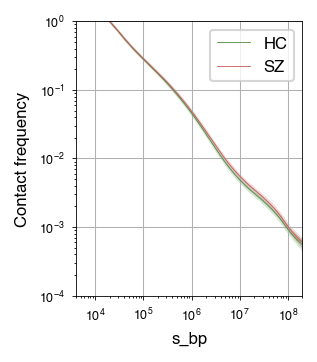

In [9]:
df_scal = pd.DataFrame(pd.concat([scaling_df['HCM12minus'], scaling_df['HC-3Mminus'], scaling_df['HC24minus'], 
                                  scaling_df['HC-318minus'], scaling_df['HC-91minus'], scaling_df['HC-2Mminus'],
                                  scaling_df['SZ-01minus'], scaling_df['SZ20minus'], scaling_df['SZ10minus'], 
                                  scaling_df['SZ08minus'], scaling_df['SZ-03minus'], scaling_df['SZ6minus']], axis = 0))

df_scal['s_bp'] = list(scaling_df['s_bp']) * 12
df_scal[''] = ['HC']*len(scaling_df)*6 + ['SZ']*len(scaling_df)*6
df_scal.columns = ['Contact frequency', 's_bp', '']
df_scal = df_scal.reset_index(drop=True)
#df_scal = df_scal.iloc[:4000]
res_scal=5000

# Plot scaling
f, axs = plt.subplots(1, 1, dpi=150, sharex=True, 
                  figsize=(2, 2.3), 
                  layout="constrained")



groups_colors = {'HC': '#4e893f',
                 'SZ': '#c35959'}

i,k = -0.05,-0.05

#plt.plot([3e6, 3e6], [0, 2], 'k--', alpha=0.3)

plt.xlim([4000, 2e8])
plt.ylim([1e-4, 1])
#plt.adjustable("box")
#plt.aspect(1)
plt.grid(lw=0.5)
plt.ylabel('Contact frequency')
plt.legend()
plt.xscale('log')
plt.yscale('log')

sns.lineplot(df_scal, x = 's_bp', y = 'Contact frequency', hue = '', palette = groups_colors)


#plt.tight_layout()    
    
plt.savefig('picture_results/Scaling_all_glia.svg',bbox_inches='tight')

/tmp/ipykernel_2835741/3176965885.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaling_df_mean['HC young'] = np.mean(scaling_df[['HCM12minus', 'HC-3Mminus']], axis = 1)
/tmp/ipykernel_2835741/3176965885.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaling_df_mean['HC old'] = np.mean(scaling_df[['HC24minus', 'HC-318minus', 'HC-91minus', 'HC-2Mminus']], axis = 1)
/tmp/ipykernel_2835741/3176965885.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

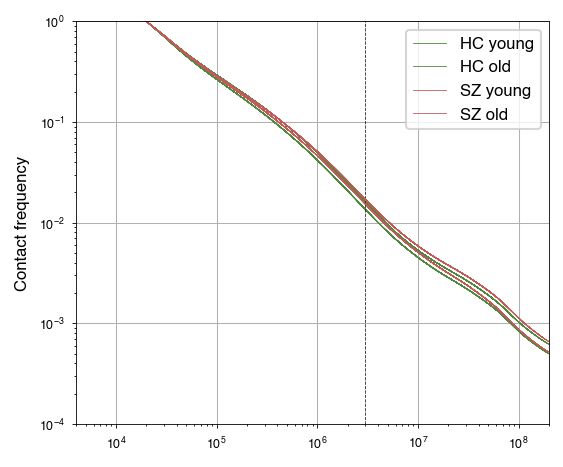

In [18]:
scaling_df_mean = scaling_df[['s_bp']]
scaling_df_mean['HC young'] = np.mean(scaling_df[['HCM12minus', 'HC-3Mminus']], axis = 1)
scaling_df_mean['HC old'] = np.mean(scaling_df[['HC24minus', 'HC-318minus', 'HC-91minus', 'HC-2Mminus']], axis = 1)
scaling_df_mean['SZ young'] = np.mean(scaling_df[['SZ-01minus', 'SZ20minus']], axis = 1)
scaling_df_mean['SZ old'] = np.mean(scaling_df[['SZ10minus', 'SZ08minus', 'SZ-03minus', 'SZ6minus']], axis = 1)
scaling_df_mean = scaling_df_mean[['s_bp', 'HC young', 'HC old', 'SZ young', 'SZ old']]
res_scal=5000

# Plot scaling
f, axs = plt.subplots(1, 1, dpi=150, sharex=True, 
                  figsize=(4, 3), 
                  layout="constrained")


groups_colors = {'HC young': '#4e893f',
                 'HC old': '#4e893f',
                 'SZ young': '#c35959',
                 'SZ old': '#c35959'}

i,k = -0.05,-0.05
for name in scaling_df_mean.columns[1:]:
        
    ax = axs
    ax.plot([3e6, 3e6], [1e-4, 1], 'k--', alpha=0.3)
    ax.loglog(
        scaling_df_mean['s_bp'],
        scaling_df_mean[name], c=groups_colors[name], #alpha = dd,
        label=name)


    ax.set(
        ylabel='Contact frequency')

    ax.set_xlim([4000, 2e8])
    ax.set_ylim([1e-4, 1])
    ax.set_adjustable("box")
    ax.set_aspect(1)
    ax.grid(lw=0.5)
    ax.legend()

    #plt.savefig(f'/home/kmorozov/figs/scalings_age_effect/{reg} {ctype}.png',dpi=100,bbox_inches='tight')

In [7]:
scaling_df_mean = scaling_df[['s_bp']]
scaling_df_mean['HC young'] = np.mean(scaling_df[['HCM12minus', 'HC-3Mminus']], axis = 1)
scaling_df_mean['HC old'] = np.mean(scaling_df[['HC24minus', 'HC-318minus', 'HC-91minus', 'HC-2Mminus']], axis = 1)
scaling_df_mean['SZ young'] = np.mean(scaling_df[['SZ-01minus', 'SZ20minus']], axis = 1)
scaling_df_mean['SZ old'] = np.mean(scaling_df[['SZ10minus', 'SZ08minus', 'SZ-03minus', 'SZ6minus']], axis = 1)
scaling_df_mean['HC o/y'] = scaling_df_mean['HC old']/scaling_df_mean['HC young']
scaling_df_mean['SZ o/y'] = scaling_df_mean['SZ old']/scaling_df_mean['SZ young']
scaling_df_mean = scaling_df_mean[['s_bp', 'HC o/y', 'SZ o/y']]
scaling_df_mean = scaling_df_mean.dropna()
scaling_df_mean

/tmp/ipykernel_3512303/618163377.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaling_df_mean['HC young'] = np.mean(scaling_df[['HCM12minus', 'HC-3Mminus']], axis = 1)
/tmp/ipykernel_3512303/618163377.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaling_df_mean['HC old'] = np.mean(scaling_df[['HC24minus', 'HC-318minus', 'HC-91minus', 'HC-2Mminus']], axis = 1)
/tmp/ipykernel_3512303/618163377.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try u

,s_bp,HC o/y,SZ o/y
2,20000,1.000000,1.000000
3,30000,1.026986,1.007253
4,40000,1.047861,1.011716
5,50000,1.063692,1.014482
6,60000,1.076133,1.017084
...,...,...,...
287504,50770000,1.216128,1.260217
287505,50780000,1.216129,1.260231
287506,50790000,1.216129,1.260244
287507,50800000,1.216130,1.260258


In [8]:
scaling_df_mean = scaling_df_mean.drop_duplicates()

/tmp/ipykernel_2835741/3617556368.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


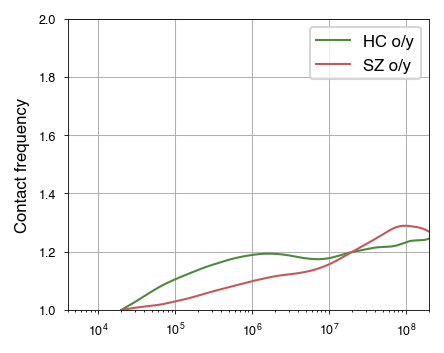

In [21]:
mpl.rc('lines', linewidth=1)
mpl.rc('font', family='Helvetica', size=8, )
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=6)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=6)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400

res_scal=5000

# Plot scaling
f, axs = plt.subplots(1, 1, dpi=150, sharex=True, 
                  figsize=(3, 2.4), 
                  layout="constrained")


groups_colors = {'HC o/y': '#4e893f',
                 'SZ o/y': '#c35959'}

i,k = -0.05,-0.05
for name in scaling_df_mean.columns[1:]:
        
    ax = axs
    ax.plot([3e6, 3e6], [1e-4, 1], 'k--', alpha=0.3)
    ax.plot(
        scaling_df_mean['s_bp'],
        scaling_df_mean[name], c=groups_colors[name], #alpha = dd,
        label=name)


    ax.set(
        ylabel='Contact frequency')

    ax.set_xlim([4000, 2e8])
    ax.set_ylim([1, 2])
    ax.set_adjustable("box")
    #ax.set_aspect(1)
    ax.grid(lw=0.5, axis='both')
    ax.legend()
    ax.set_xscale('log')

plt.tight_layout()

plt.savefig('picture_results/Scaling_aging_glia.svg',bbox_inches='tight')

In [9]:
scaling_df_mean_var = scaling_df[['s_bp']]

for hc_o in ['HC24minus', 'HC-318minus', 'HC-91minus', 'HC-2Mminus']:
    for hc_y in ['HCM12minus', 'HC-3Mminus']:
        scaling_df_mean_var[f'{hc_o}/{hc_y}'] = scaling_df[hc_o]/scaling_df[hc_y]

for sz_o in ['SZ10minus', 'SZ08minus', 'SZ-03minus', 'SZ6minus']:
    for sz_y in ['SZ-01minus', 'SZ20minus']:
        scaling_df_mean_var[f'{sz_o}/{sz_y}'] = scaling_df[sz_o]/scaling_df[sz_y]

df_scal_var = pd.DataFrame()

for col in scaling_df_mean_var.columns[1:]:
    df = pd.DataFrame()
    df['s_bp'] = scaling_df_mean_var['s_bp']
    if 'HC' in col:
        df['data'] = scaling_df_mean_var[col]
        df[''] = 'HC o/y'
    elif 'SZ' in col:
        df['data'] = scaling_df_mean_var[col]
        df[''] = 'SZ o/y'
    df_scal_var = pd.concat([df_scal_var, df])

df_scal_var = df_scal_var.dropna()
df_scal_var

/tmp/ipykernel_3512303/3612195794.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaling_df_mean_var[f'{hc_o}/{hc_y}'] = scaling_df[hc_o]/scaling_df[hc_y]
/tmp/ipykernel_3512303/3612195794.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaling_df_mean_var[f'{hc_o}/{hc_y}'] = scaling_df[hc_o]/scaling_df[hc_y]
/tmp/ipykernel_3512303/3612195794.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See

,s_bp,data,
2,20000,1.000000,HC o/y
3,30000,1.024412,HC o/y
4,40000,1.045046,HC o/y
5,50000,1.062821,HC o/y
6,60000,1.078139,HC o/y
...,...,...,...
287504,50770000,1.049714,SZ o/y
287505,50780000,1.049735,SZ o/y
287506,50790000,1.049756,SZ o/y
287507,50800000,1.049778,SZ o/y


/tmp/ipykernel_3512303/3178643202.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


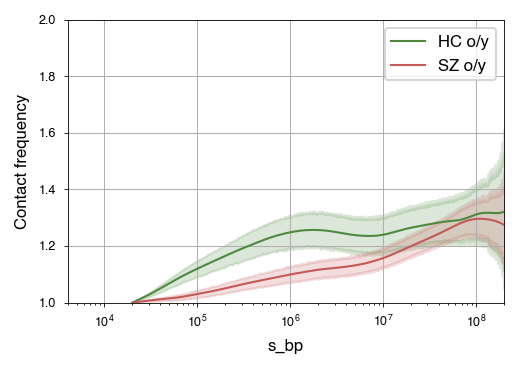

In [11]:
mpl.rc('lines', linewidth=1)
mpl.rc('font', family='Helvetica', size=8, )
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=6)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=6)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400


# Plot scaling

plt.figure(figsize=(3.5, 2.5), dpi=150)


groups_colors = {'HC o/y': '#4e893f',
                 'SZ o/y': '#c35959'}

i,k = -0.05,-0.05

#plt.plot([3e6, 3e6], [0, 2], 'k--', alpha=0.3)


plt.ylabel('Contact frequency')

plt.xlim([4000, 2e8])
plt.ylim([1, 2])
#plt.adjustable("box")
#plt.aspect(1)
plt.grid(lw=0.5, axis='both')
plt.legend()
plt.xscale('log')

sns.lineplot(df_scal_var, x = 's_bp', y = 'data', hue = '', palette = groups_colors)


    

plt.tight_layout()

plt.savefig('picture_results/Scaling_var_glia.svg',bbox_inches='tight')

## ICF

100%|██████████| 12/12 [03:28<00:00, 17.38s/it]


Text(0, 0.5, 'ICF')

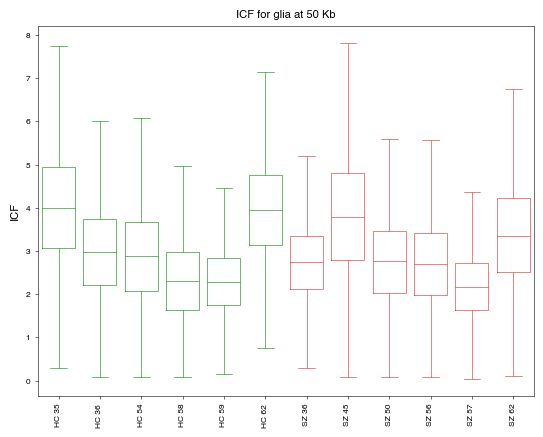

In [3]:
ages = {
    'HC-2Mplus':'HC 62 2M',
    'HC-2Mminus':'HC 62 2M',
    'HC-3Mplus':'HC 36 3M',
    'HC-3Mminus':'HC 36 3M',
    'HC-318plus':'HC 58 318',
    'HC-318minus':'HC 58 318',
    'HC-91plus':'HC 59 91',
    'HC-91minus':'HC 59 91',
    'HC24plus':'HC 54 24',
    'HC24minus':'HC 54 24',
    'HCM12plus':'HC 35 12M',
    'HCM12minus':'HC 35 12M',
    'SZ-01plus':'SZ 36 01',
    'SZ-01minus':'SZ 36 01',
    'SZ-03plus':'SZ 57 03',
    'SZ-03minus':'SZ 57 03',
    'SZ08plus':'SZ 56 08',
    'SZ08minus':'SZ 56 08',
    'SZ10plus':'SZ 50 10',
    'SZ10minus':'SZ 50 10',
    'SZ20plus':'SZ 45 20',
    'SZ20minus':'SZ 45 20',
    'SZ6plus':'SZ 62 06',
    'SZ6minus':'SZ 62 06'
}

# compute expected
cvd = {'HC': {'NeuN+': {}, 'NeuN-': {}}, 
       'SZ': {'NeuN+': {}, 'NeuN-': {}}}

res = 50_000

clr_dir = '/tank/projects/kmorozov/SZ_check_pol/'
clr_names = {
            'HC-2Mminus': 'HC-2Mminus.sampled.drop_diag.1kb.mcool',
            'HC24minus': 'HC24minus.sampled.drop_diag.1kb.mcool',
            'HC-91minus': 'HC-91minus.sampled.drop_diag.1kb.mcool',
            'HC-318minus': 'HC-318minus.drop_diag.1kb.mcool',
            'HCM12minus': 'HCM12minus.sampled.drop_diag.1kb.mcool',
            'HC-3Mminus': 'HC-3Mminus.sampled.drop_diag.1kb.mcool',

            'SZ-01minus': 'SZ-01minus.sampled.drop_diag.1kb.mcool',
            'SZ-03minus': 'SZ-03minus.sampled.drop_diag.1kb.mcool',
            'SZ6minus': 'SZ6minus.sampled.drop_diag.1kb.mcool',
            'SZ08minus': 'SZ08minus.sampled.drop_diag.1kb.mcool',
            'SZ10minus': 'SZ10minus.sampled.drop_diag.1kb.mcool',
            'SZ20minus': 'SZ20minus.sampled.drop_diag.1kb.mcool',
}



clrs = {name: cooler.Cooler(clr_dir + clr_names[name] + f'::resolutions/{res}') for name in clr_names.keys()}

chroms = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6',
 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14',
 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22']


def compute_ICF(hiclist, dropdiag=0, resolution=50000, stable=True, normalized=False):
    """
    This function returns a dictionary where keys are names of Hi-C matrices
    and values are matrices of cis-trans contact sums.
    
    hiclist :: [str] - list of paths to .mcool files
    dropdiag :: int - number of diags to drop (main diagonal counts from 1)
    resolution :: int - desired resolution for Hi-C matrix
    stable :: bool - whether to add 1 to contact sums matrix (for numerical 
                     stability at logarithm computation)
    normalized :: bool - whether to normalize matrix with a total sum of contacts
    """

    icf={}

    for path in tqdm(hiclist):
        
        clr = cooler.Cooler(path + '::/resolutions/%d' % resolution)
        f = path.split('/')[-1].split('.')[0]
        name = ages[f]
        bins = pd.DataFrame(clr.bins()[:].drop(columns=['start', 'end']))
        #bins = bins[bins['chrom'].isin(chroms)]
        pix = clr.pixels()[:]
        pix_no_diag = pix[pix.bin2_id >= pix.bin1_id + dropdiag]
        pix_no_diag = pd.DataFrame(pix_no_diag.merge(bins, left_on='bin1_id', right_index=True).\
                                merge(bins, left_on='bin2_id', right_index=True))
        m = pix_no_diag[(pix_no_diag['chrom_x'].isin(chroms))&(pix_no_diag['chrom_y'].isin(chroms))]
        m_diag = m[(m['chrom_x'] == m['chrom_y'])]
        m_nediag = m[(m['chrom_x'] != m['chrom_y'])]
        x_diag = m_diag.groupby('bin1_id')['count'].sum()
        y_diag = m_diag.groupby('bin2_id')['count'].sum()
        x_nediag = m_nediag.groupby('bin1_id')['count'].sum()
        y_nediag = m_nediag.groupby('bin2_id')['count'].sum()
        diag = pd.DataFrame(pd.merge(x_diag, y_diag, left_index=True, right_index=True))
        diag['sum_inter'] = diag['count_x']+diag['count_y']
        nediag = pd.DataFrame(pd.merge(x_nediag, y_nediag, left_index=True, right_index=True))
        nediag['sum_intra'] = nediag['count_x']+nediag['count_y']
        final_df = pd.DataFrame(pd.merge(diag, nediag, left_index=True, right_index=True))
        final_df['ICF'] = final_df['sum_inter']/final_df['sum_intra']
        final_df = final_df.reset_index()

        icf[name]=final_df[['index', 'ICF']]

    return icf

phenotypes = [  ['HC-2Mminus', 'HC_minus_old', 'old', 'HC'],
                ['HC24minus', 'HC_minus_old', 'middle', 'HC'],
                ['HC-318minus', 'HC_minus_old', 'middle', 'HC'], 
                ['HC-91minus', 'HC_minus_old', 'old', 'HC'],
                ['HC-3Mminus', 'HC_minus_young', 'young', 'HC'],
                ['HCM12minus', 'HC_minus_young', 'young', 'HC'],
                ['SZ-01minus', 'SZ_minus_young', 'young', 'SZ'],
                ['SZ-03minus', 'SZ_minus_old', 'old', 'SZ'],
                ['SZ6minus', 'SZ_minus_old', 'old', 'SZ'],
                ['SZ08minus', 'SZ_minus_old', 'middle', 'SZ'],
                ['SZ10minus', 'SZ_minus_old', 'middle', 'SZ'],
                ['SZ20minus', 'SZ_minus_young', 'young', 'SZ'],
                       ]

lst = ['/tank/projects/kmorozov/SZ_check_pol/' + clr_names[phen[0]] for phen in phenotypes]
icf = compute_ICF(lst, dropdiag=0, resolution=50000, stable=True, normalized=False)

dic_icf = icf[list(icf.keys())[0]]
dic_icf.columns = ['index', list(icf.keys())[0]]
for i in list(icf.keys())[1:]:
    a = icf[i]
    a.columns = ['index', i]
    dic_icf = pd.merge(dic_icf, icf[i], left_on = 'index', right_on='index')

dic_icf = dic_icf.drop(columns = ['index'])
dic_icf = dic_icf.dropna()
dic_icf

sns.boxplot(dic_icf,showfliers=False, order = ['HC 35 12M', 'HC 36 3M', 'HC 54 24', 'HC 58 318', 'HC 59 91',
 'HC 62 2M', 'SZ 36 01', 'SZ 45 20', 'SZ 50 10', 'SZ 56 08', 'SZ 57 03', 'SZ 62 06'],palette=['green','green','green','green','green','green',
                                                                                           '#CD2626','#CD2626','#CD2626',
                                                                                           '#CD2626','#CD2626','#CD2626'],
           fill=False)
plt.xticks(['HC 35 12M', 'HC 36 3M', 'HC 54 24', 'HC 58 318', 'HC 59 91',
 'HC 62 2M', 'SZ 36 01', 'SZ 45 20', 'SZ 50 10', 'SZ 56 08', 'SZ 57 03', 'SZ 62 06'],['HC 35', 'HC 36', 'HC 54', 'HC 58', 'HC 59',
 'HC 62', 'SZ 36', 'SZ 45', 'SZ 50', 'SZ 56', 'SZ 57', 'SZ 62'],rotation=90)
plt.title('ICF for glia at 50 Kb')
plt.ylabel('ICF')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC vs. SZ: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=1.543e+12


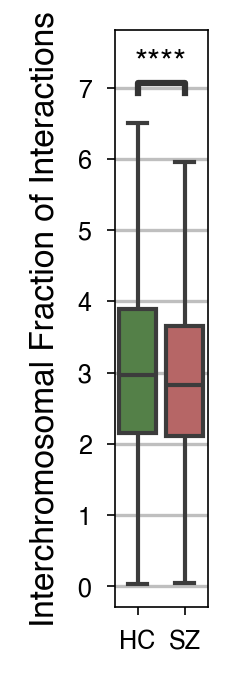

In [12]:

name_dict = {'HC 35 12M': 'HC', 'HC 36 3M': 'HC', 'HC 54 24': 'HC', 'HC 58 318': 'HC', 'HC 59 91': 'HC', 'HC 62 2M': 'HC', 
 'SZ 36 01': 'SZ', 'SZ 45 20': 'SZ', 'SZ 50 10': 'SZ', 'SZ 56 08': 'SZ', 'SZ 57 03': 'SZ', 'SZ 62 06': 'SZ'}
icf_hcsz = dic_icf.rename(columns = name_dict)



f, axs = plt.subplots(
    figsize=(0.4,2.5),
    ncols=1,
    nrows=1, dpi = 300)

groups_colors = {'HC': '#4e893f',
                 'SZ': '#c35959'}
plt.ylabel('Interchromosomal Fraction of Interactions')
boxplot = sns.boxplot(icf_hcsz, palette = groups_colors, showfliers=False, order = ['HC','SZ'])
axs.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)
pairs = [('HC', 'SZ')]

annotator = Annotator(boxplot, pairs, data=icf_hcsz)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.savefig('picture_results/ICF_all_glia.svg',bbox_inches='tight')


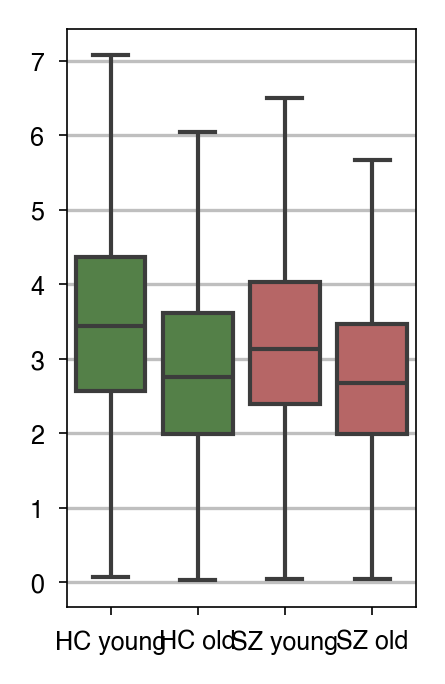

In [13]:

name_dict = {'HC 35 12M': 'HC young', 'HC 36 3M': 'HC young', 'HC 54 24': 'HC old', 'HC 58 318': 'HC old', 'HC 59 91': 'HC old', 'HC 62 2M': 'HC old', 
 'SZ 36 01': 'SZ young', 'SZ 45 20': 'SZ young', 'SZ 50 10': 'SZ old', 'SZ 56 08': 'SZ old', 'SZ 57 03': 'SZ old', 'SZ 62 06': 'SZ old'}
icf_youngold = dic_icf.rename(columns = name_dict)





f, axs = plt.subplots(
    figsize=(1.5, 2.5),
    ncols=1,
    nrows=1, dpi = 300)

groups_colors = {'HC young': '#4e893f',
                 'HC old': '#4e893f',
                 'SZ young': '#c35959',
                 'SZ old': '#c35959'}

boxplot = sns.boxplot(icf_youngold, palette = groups_colors, showfliers=False, order = ['HC young', 'HC old', 'SZ young', 'SZ old'])
axs.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)
pairs = [('HC young', 'HC old'), ('SZ young', 'SZ old')]

#annotator = Annotator(boxplot, pairs, data=dlr_youngold)
#annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
#annotator.apply_and_annotate()
plt.savefig('picture_results/ICF_aging_glia_all.svg',bbox_inches='tight')



p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC
o/y vs. SZ
o/y: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=8.732e+08


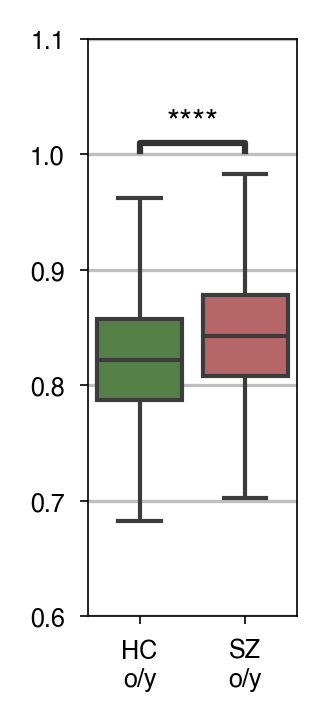

In [14]:
dic_icf_mean = pd.DataFrame()
dic_icf_mean['HC young'] = np.mean(dic_icf[['HC 35 12M', 'HC 36 3M']], axis = 1)
dic_icf_mean['HC old'] = np.mean(dic_icf[['HC 54 24', 'HC 58 318', 'HC 59 91', 'HC 62 2M']], axis = 1)
dic_icf_mean['SZ young'] = np.mean(dic_icf[['SZ 36 01', 'SZ 45 20']], axis = 1)
dic_icf_mean['SZ old'] = np.mean(dic_icf[['SZ 50 10', 'SZ 56 08', 'SZ 57 03', 'SZ 62 06']], axis = 1)
dic_icf_mean['HC\no/y'] = dic_icf_mean['HC old']/dic_icf_mean['HC young']
dic_icf_mean['SZ\no/y'] = dic_icf_mean['SZ old']/dic_icf_mean['SZ young']
dic_icf_mean = dic_icf_mean[['HC\no/y', 'SZ\no/y']]
dic_icf_mean

f, axs = plt.subplots(
    figsize=(0.9, 2.5),
    ncols=1,
    nrows=1, dpi = 300)

groups_colors = {'HC\no/y': '#4e893f',
                 'SZ\no/y': '#c35959'}

boxplot = sns.boxplot(dic_icf_mean, palette = groups_colors, showfliers=False, order = ['HC\no/y', 'SZ\no/y'])

plt.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)

pairs = [('HC\no/y', 'SZ\no/y')]

annotator = Annotator(boxplot, pairs, data=dic_icf_mean)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
plt.ylim(0.6, 1.1)

plt.savefig('picture_results/ICF_aging_glia.svg',bbox_inches='tight')


## Cis-trans

In [23]:
# compute expected
cvd = {'HC': {'NeuN+': {}, 'NeuN-': {}}, 
       'SZ': {'NeuN+': {}, 'NeuN-': {}}}

res = 100_000

clr_dir = '../data/'
clr_names = {
            'HC-2Mminus': 'HC-2Mminus.sampled.drop_diag.1kb.mcool',
            'HC24minus': 'HC24minus.sampled.drop_diag.1kb.mcool',
            'HC-91minus': 'HC-91minus.sampled.drop_diag.1kb.mcool',
            'HC-318minus': 'HC-318minus.drop_diag.1kb.mcool',
            'HCM12minus': 'HCM12minus.sampled.drop_diag.1kb.mcool',
            'HC-3Mminus': 'HC-3Mminus.sampled.drop_diag.1kb.mcool',

            'SZ-01minus': 'SZ-01minus.sampled.drop_diag.1kb.mcool',
            'SZ-03minus': 'SZ-03minus.sampled.drop_diag.1kb.mcool',
            'SZ6minus': 'SZ6minus.sampled.drop_diag.1kb.mcool',
            'SZ08minus': 'SZ08minus.sampled.drop_diag.1kb.mcool',
            'SZ10minus': 'SZ10minus.sampled.drop_diag.1kb.mcool',
            'SZ20minus': 'SZ20minus.sampled.drop_diag.1kb.mcool',
}


clrs = {name: cooler.Cooler(clr_dir + clr_names[name] + f'::resolutions/{res}') for name in clr_names.keys()}

def compute_cis_trans(hiclist, dropdiag=0, resolution=100000, stable=True, normalized=False):
    """
    This function returns a dictionary where keys are names of Hi-C matrices
    and values are matrices of cis-trans contact sums.
    
    hiclist :: [str] - list of paths to .mcool files
    dropdiag :: int - number of diags to drop (main diagonal counts from 1)
    resolution :: int - desired resolution for Hi-C matrix
    stable :: bool - whether to add 1 to contact sums matrix (for numerical 
                     stability at logarithm computation)
    normalized :: bool - whether to normalize matrix with a total sum of contacts
    """
    interchrom = {}
    for path in tqdm(hiclist):
        clr = cooler.Cooler(path + '::/resolutions/%d' % resolution)
       # clr = cooler.Cooler(path)
        sizes = np.array(clr.chromsizes.values) / resolution #compute normalization matrix
        norm = np.outer(sizes, sizes)

        pix = clr.pixels()[:]
        pix_no_diag = pix[pix.bin2_id >= pix.bin1_id + dropdiag] #delete m first diagonals
        bins = clr.bins()[:].drop(columns=['start', 'end'])
        cis_trans = np.asarray(
                    pix_no_diag.merge(bins, left_on='bin1_id', right_index=True).\
                                merge(bins, left_on='bin2_id', right_index=True).\
                                groupby(['chrom_x', 'chrom_y']).sum().\
                                unstack(fill_value=0)['count']) #convert to square matrix

        cis_trans = cis_trans + cis_trans.T - np.diag(np.diag(cis_trans))
        if normalized:
            fullsum = np.nansum(cis_trans)
            if fullsum == 0.:
                print('Drop %s due to zero contact sum' % path)
                continue
            cis_trans = cis_trans / fullsum * 2 * 1_000_000 #scale by constant
        if stable:
            cis_trans += 1
        result = cis_trans / norm
        interchrom[os.path.splitext(os.path.basename(clr.filename))[0]] = result 
    return interchrom

phenotypes = [  ['HC-2Mminus', 'HC_minus_old', 'old', 'HC'],
                ['HC24minus', 'HC_minus_old', 'middle', 'HC'],
                ['HC-318minus', 'HC_minus_old', 'middle', 'HC'], 
                ['HC-91minus', 'HC_minus_old', 'old', 'HC'],
                ['HC-3Mminus', 'HC_minus_young', 'young', 'HC'],
                ['HCM12minus', 'HC_minus_young', 'young', 'HC'],
                ['SZ-01minus', 'SZ_minus_young', 'young', 'SZ'],
                ['SZ-03minus', 'SZ_minus_old', 'old', 'SZ'],
                ['SZ6minus', 'SZ_minus_old', 'old', 'SZ'],
                ['SZ08minus', 'SZ_minus_old', 'middle', 'SZ'],
                ['SZ10minus', 'SZ_minus_old', 'middle', 'SZ'],
                ['SZ20minus', 'SZ_minus_young', 'young', 'SZ'],
                       ]

lst = ['../data/' + clr_names[phen[0]] for phen in phenotypes]

interactions50000_new = compute_cis_trans(lst, dropdiag=0, resolution=100000, stable=True, normalized=False)

interactions50000_new_keys = [i for i in interactions50000_new.keys()]
interactions50000_new_keys.sort(reverse=True)
interactions50000_new_keys

interactions50000_new['hc_minus_young.sampled.drop_diag.1kb'] = np.mean([interactions50000_new['HCM12minus.sampled.drop_diag.1kb'], interactions50000_new['HC-3Mminus.sampled.drop_diag.1kb']], axis = 0)                                                                    
interactions50000_new['hc_minus_old.sampled.drop_diag.1kb'] = np.mean([interactions50000_new['HC-2Mminus.sampled.drop_diag.1kb'], interactions50000_new['HC-91minus.sampled.drop_diag.1kb'], interactions50000_new['HC-318minus.drop_diag.1kb'], interactions50000_new['HC24minus.sampled.drop_diag.1kb']], axis = 0)
interactions50000_new['sz_minus_young.sampled.drop_diag.1kb'] = np.mean([interactions50000_new['SZ-01minus.sampled.drop_diag.1kb'], interactions50000_new['SZ20minus.sampled.drop_diag.1kb']], axis = 0)
interactions50000_new['sz_minus_old.sampled.drop_diag.1kb'] = np.mean([interactions50000_new['SZ10minus.sampled.drop_diag.1kb'], interactions50000_new['SZ-03minus.sampled.drop_diag.1kb'], interactions50000_new['SZ6minus.sampled.drop_diag.1kb'], interactions50000_new['SZ08minus.sampled.drop_diag.1kb'], ], axis = 0)
interactions50000_new['hc_minus.sampled.drop_diag.1kb'] = np.mean([interactions50000_new['HCM12minus.sampled.drop_diag.1kb'], interactions50000_new['HC-3Mminus.sampled.drop_diag.1kb'], interactions50000_new['HC-2Mminus.sampled.drop_diag.1kb'], interactions50000_new['HC-91minus.sampled.drop_diag.1kb'], interactions50000_new['HC-318minus.drop_diag.1kb'], interactions50000_new['HC24minus.sampled.drop_diag.1kb']], axis = 0)
interactions50000_new['sz_minus.sampled.drop_diag.1kb'] = np.mean([interactions50000_new['SZ-01minus.sampled.drop_diag.1kb'], interactions50000_new['SZ20minus.sampled.drop_diag.1kb'], interactions50000_new['SZ10minus.sampled.drop_diag.1kb'], interactions50000_new['SZ-03minus.sampled.drop_diag.1kb'], interactions50000_new['SZ6minus.sampled.drop_diag.1kb'], interactions50000_new['SZ08minus.sampled.drop_diag.1kb']], axis = 0)
chroms = clrs['HCM12minus'].chromnames                                                        

ERROR! Session/line number was not unique in database. History logging moved to new session 78


  0%|          | 0/12 [00:00<?, ?it/s]/tmp/ipykernel_2835741/1969750524.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby(['chrom_x', 'chrom_y']).sum().\
  8%|▊         | 1/12 [00:08<01:28,  8.04s/it]/tmp/ipykernel_2835741/1969750524.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby(['chrom_x', 'chrom_y']).sum().\
 17%|█▋        | 2/12 [00:17<01:28,  8.84s/it]/tmp/ipykernel_2835741/1969750524.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt 

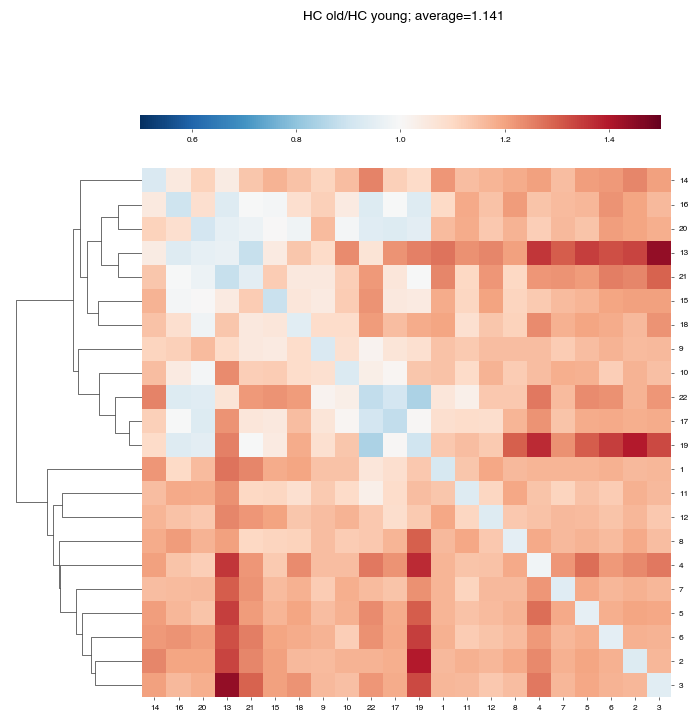

In [24]:
#####HC

selected_keys = ['hc_minus_young.sampled.drop_diag.1kb',
 'hc_minus_old.sampled.drop_diag.1kb']

map1 = interactions50000_new[selected_keys[0]][:-3, :-3] # -1 is for ignoring of the last chromosome
map2 = interactions50000_new[selected_keys[1]][:-3, :-3]
m = map2 / map1
names_samples = []
for i in selected_keys:
    if 'plus' in i:
            names_samples.append(i.split('_')[1].replace("plus", "neurons"))
    if 'minus' in i :
            names_samples.append(i.split('_')[1].replace("minus", "glia"))

df_corr = pd.DataFrame(m)
df_corr.index = chroms[:22]
df_corr.columns = chroms[:22]
df_corr.columns = [i.split("chr")[1] for i in df_corr.columns.tolist()]
df_corr.index =  df_corr.columns.tolist()


g = sns.clustermap(df_corr, figsize = (7,7),
                   cbar_kws={"orientation": "horizontal"},
                   metric="correlation", cmap="RdBu_r", vmax=1.5, vmin=0.5)
x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([x0+0.183, 0.85, g.ax_row_dendrogram.get_position().width+0.555, 0.02])

g.fig.suptitle("HC old" + '/' + "HC young" + '; average=%.3f' % np.nanmean(m),  y=1.02, x =0.58)

plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=1)
#plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=1)

sns.set_style("ticks")

g.ax_row_dendrogram.set_visible(True)
g.ax_col_dendrogram.set_visible(False)

# dendro_box = g.ax_row_dendrogram.get_position()
# dendro_box.x0 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# dendro_box.x1 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# g.cax.set_position(dendro_box)
#g.cax.yaxis.set_ticks_position("default")

#plt.tight_layout()

#plt.savefig('picture_results/Cistrans_HC_glia.svg',bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC vs. SZ: Mann-Whitney-Wilcoxon test two-sided, P_val:8.235e-01 U_stat=2.520e+02


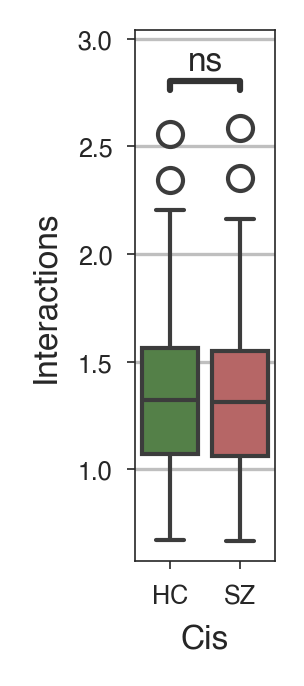

In [46]:
m_hc = interactions50000_new['hc_minus.sampled.drop_diag.1kb'][:-3, :-3]
m_hc_intra = list(np.diag(m_hc))
m_hc_inter = list(m_hc[np.triu_indices_from(m_hc, k=1)])

m_sz = interactions50000_new['sz_minus.sampled.drop_diag.1kb'][:-3, :-3]
m_sz_intra = list(np.diag(m_sz))
m_sz_inter = list(m_sz[np.triu_indices_from(m_sz, k=1)])

df = pd.DataFrame({'Interactions': m_hc_intra + m_sz_intra, ' ': ['HC' for _ in range(len(m_hc_intra))] + ['SZ' for _ in range(len(m_hc_intra))], 'Interaction type': ['Cis' for _ in range(len(m_hc_intra)+len(m_sz_intra))]})
df['stat'] = df[' '] + df['Interaction type']

colormap = {'HC': '#4e893f', 
            'SZ': '#c35959'}

plt.figure(dpi=300, figsize=(0.6,2.3))
box_plot=sns.boxplot(data = df, y = 'Interactions', x = ' ', hue = ' ', palette = colormap)
plt.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)
box_plot.legend_ = None
pairs = [('HC', 'SZ')]

annotator = Annotator(box_plot, pairs, data = df, y = 'Interactions', x = ' ')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
#plt.tight_layout()
plt.xlabel('Cis')
plt.savefig('picture_results/Cis_glia.svg',bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC vs. SZ: Mann-Whitney-Wilcoxon test two-sided, P_val:1.864e-01 U_stat=2.478e+04


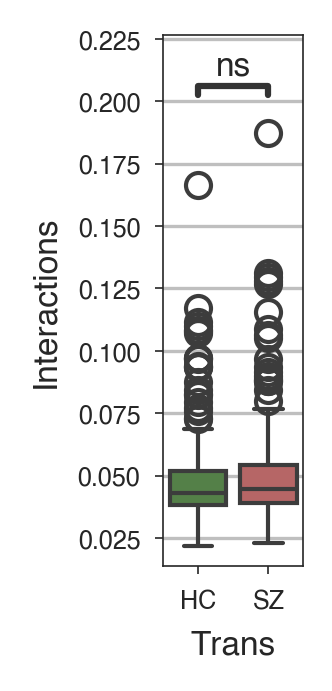

In [47]:
m_hc = interactions50000_new['hc_minus.sampled.drop_diag.1kb'][:-3, :-3]
m_hc_intra = list(np.diag(m_hc))
m_hc_inter = list(m_hc[np.triu_indices_from(m_hc, k=1)])

m_sz = interactions50000_new['sz_minus.sampled.drop_diag.1kb'][:-3, :-3]
m_sz_intra = list(np.diag(m_sz))
m_sz_inter = list(m_sz[np.triu_indices_from(m_sz, k=1)])

df = pd.DataFrame({'Interactions': m_hc_inter + m_sz_inter, ' ': ['HC' for _ in range(len(m_hc_inter))] + ['SZ' for _ in range(len(m_hc_inter))], 'Interaction type': ['Cis' for _ in range(len(m_hc_inter)+len(m_sz_inter))]})
df['stat'] = df[' '] + df['Interaction type']

colormap = {'HC': '#4e893f', 
            'SZ': '#c35959'}

plt.figure(dpi=300, figsize=(0.6,2.3))
box_plot=sns.boxplot(data = df, y = 'Interactions', x = ' ', hue = ' ', palette = colormap)
plt.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)
box_plot.legend_ = None
pairs = [('HC', 'SZ')]

annotator = Annotator(box_plot, pairs, data = df, y = 'Interactions', x = ' ')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
#plt.tight_layout()
plt.xlabel('Trans')
plt.savefig('picture_results/Trans_glia.svg',bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC o/y
Cis vs. SZ o/y
Cis: Mann-Whitney-Wilcoxon test two-sided, P_val:2.962e-01 U_stat=2.870e+02
HC o/y
Trans vs. SZ o/y
Trans: Mann-Whitney-Wilcoxon test two-sided, P_val:1.392e-18 U_stat=3.930e+04


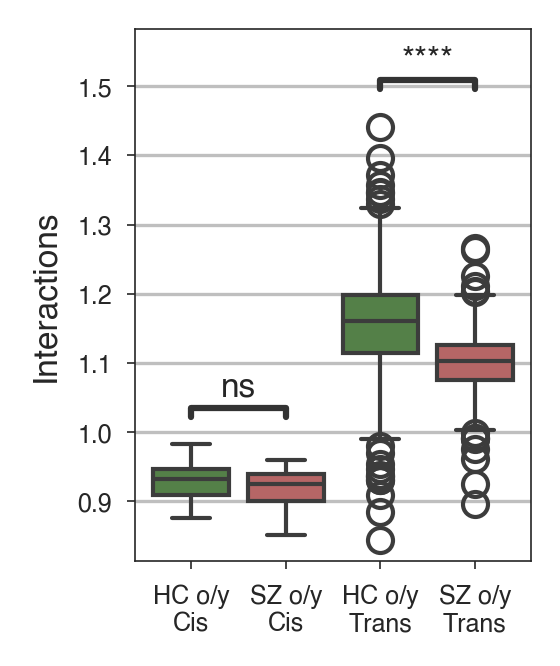

In [48]:
selected_keys = ['hc_minus_young.sampled.drop_diag.1kb',
 'hc_minus_old.sampled.drop_diag.1kb']
map1 = interactions50000_new[selected_keys[0]][:-3, :-3] # -1 is for ignoring of the last chromosome
map2 = interactions50000_new[selected_keys[1]][:-3, :-3]
m_hc = map2 / map1
m_hc_intra = list(np.diag(m_hc))
m_hc_inter = list(m_hc[np.triu_indices_from(m_hc, k=1)])

selected_keys = ['sz_minus_young.sampled.drop_diag.1kb',
 'sz_minus_old.sampled.drop_diag.1kb']
map1 = interactions50000_new[selected_keys[0]][:-3, :-3] # -1 is for ignoring of the last chromosome
map2 = interactions50000_new[selected_keys[1]][:-3, :-3]
m_sz = map2 / map1
m_sz_intra = list(np.diag(m_sz))
m_sz_inter = list(m_sz[np.triu_indices_from(m_sz, k=1)])

df = pd.DataFrame({'Interactions': m_hc_intra + m_sz_intra + m_hc_inter + m_sz_inter, ' ': ['HC o/y' for _ in range(len(m_hc_intra))] + ['SZ o/y' for _ in range(len(m_hc_intra))] + ['HC o/y' for _ in range(len(m_hc_inter))] + ['SZ o/y' for _ in range(len(m_sz_inter))], 'Interaction type': ['Cis' for _ in range(len(m_hc_intra)+len(m_sz_intra))] + ['Trans' for _ in range(len(m_hc_inter)+len(m_sz_inter))]})
df[''] = df[' '] + '\n' + df['Interaction type']

colormap = {'HC o/y': '#4e893f', 
            'SZ o/y': '#c35959'}

plt.figure(dpi=300, figsize=(1.7,2.3))
box_plot=sns.boxplot(data = df, y = 'Interactions', x = '', hue = ' ', palette = colormap)
plt.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)
box_plot.legend_ = None
pairs = [('HC o/y\nCis', 'SZ o/y\nCis'), ('HC o/y\nTrans', 'SZ o/y\nTrans')]

annotator = Annotator(box_plot, pairs, data = df, y = 'Interactions', x = '')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()

#plt.tight_layout()
plt.savefig('picture_results/Cis_trans_aging_boxplot_glia.svg',bbox_inches='tight')

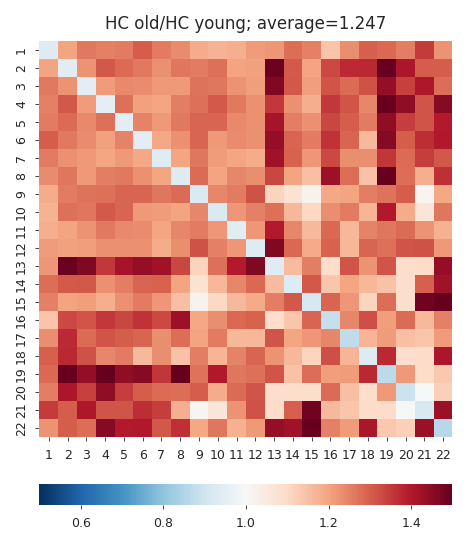

In [90]:
#####HC

selected_keys = ['hc_plus_young.sampled.drop_diag.1kb',
 'hc_plus_old.sampled.drop_diag.1kb']

map1 = interactions50000_new[selected_keys[0]][:-3, :-3] # -1 is for ignoring of the last chromosome
map2 = interactions50000_new[selected_keys[1]][:-3, :-3]
m = map2 / map1
names_samples = []
for i in selected_keys:
    if 'plus' in i:
            names_samples.append(i.split('_')[1].replace("plus", "neurons"))
    if 'minus' in i :
            names_samples.append(i.split('_')[1].replace("minus", "glia"))

df_corr = pd.DataFrame(m)
df_corr.index = chroms[:22]
df_corr.columns = chroms[:22]
df_corr.columns = [i.split("chr")[1] for i in df_corr.columns.tolist()]
df_corr.index =  df_corr.columns.tolist()

f, axs = plt.subplots(1, 1, dpi=150, sharex=True, 
                  figsize=(3, 3.5), 
                  layout="constrained")

g = sns.heatmap(df_corr, ax = axs, 
                   cbar_kws={"orientation": "horizontal"}, cmap="RdBu_r", vmax=1.5, vmin=0.5)
#x0, _y0, _w, _h = g.cbar_pos
#g.ax_cbar.set_position([x0+0.183, 0.85, g.ax_row_dendrogram.get_position().width+0.555, 0.02])

plt.title(f"HC old/HC young; average={np.nanmean(m):.3f}")

#plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=1)
#plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=1)

sns.set_style("ticks")

#g.ax_row_dendrogram.set_visible(True)
#g.ax_col_dendrogram.set_visible(False)

# dendro_box = g.ax_row_dendrogram.get_position()
# dendro_box.x0 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# dendro_box.x1 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# g.cax.set_position(dendro_box)
#g.cax.yaxis.set_ticks_position("default")

#plt.tight_layout()

plt.savefig('picture_results/Cistrans_HC_neuron.svg',bbox_inches='tight')

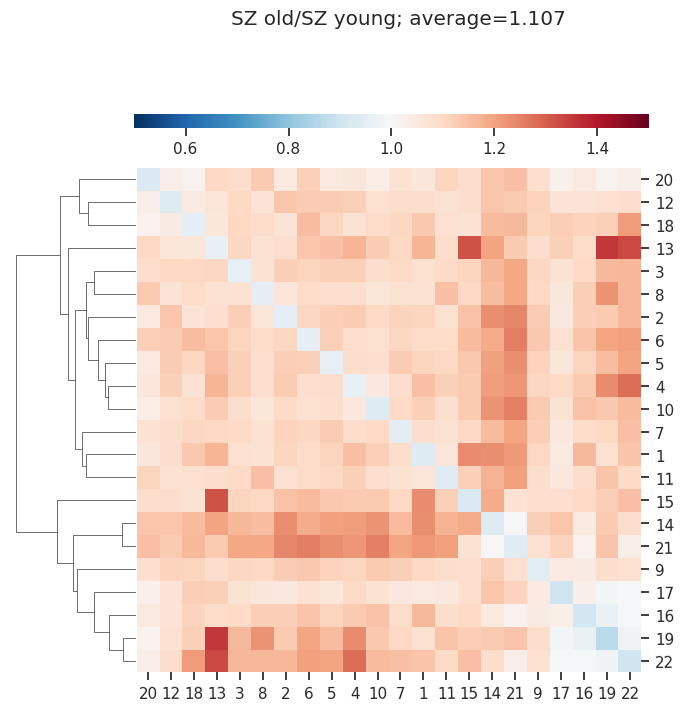

In [83]:
#####HC

selected_keys = ['sz_plus_young.sampled.drop_diag.1kb',
 'sz_plus_old.sampled.drop_diag.1kb']

map1 = interactions50000_new[selected_keys[0]][:-3, :-3] # -1 is for ignoring of the last chromosome
map2 = interactions50000_new[selected_keys[1]][:-3, :-3]
m = map2 / map1
names_samples = []
for i in selected_keys:
    if 'plus' in i:
            names_samples.append(i.split('_')[1].replace("plus", "neurons"))
    if 'minus' in i :
            names_samples.append(i.split('_')[1].replace("minus", "glia"))

df_corr = pd.DataFrame(m)
df_corr.index = chroms[:22]
df_corr.columns = chroms[:22]
df_corr.columns = [i.split("chr")[1] for i in df_corr.columns.tolist()]
df_corr.index =  df_corr.columns.tolist()


g = sns.clustermap(df_corr, figsize = (7,7),
                   cbar_kws={"orientation": "horizontal"},
                   metric="correlation", cmap="RdBu_r", vmax=1.5, vmin=0.5)
x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([x0+0.183, 0.85, g.ax_row_dendrogram.get_position().width+0.555, 0.02])

g.fig.suptitle("SZ old" + '/' + "SZ young" + '; average=%.3f' % np.nanmean(m),  y=1.02, x =0.58)

plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=1)
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=1)

sns.set_style("ticks")

g.ax_row_dendrogram.set_visible(True)
g.ax_col_dendrogram.set_visible(False)

# dendro_box = g.ax_row_dendrogram.get_position()
# dendro_box.x0 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# dendro_box.x1 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# g.cax.set_position(dendro_box)
g.cax.yaxis.set_ticks_position("default")  

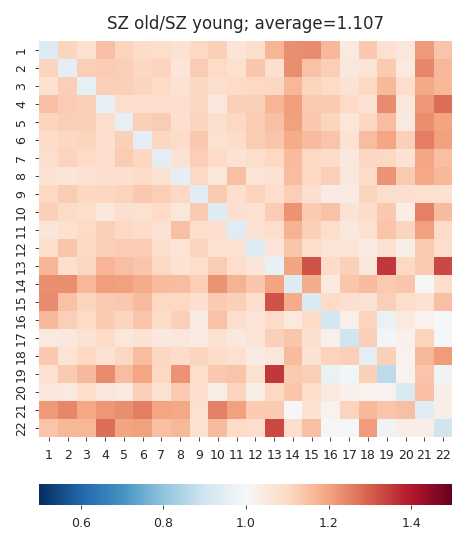

In [91]:
#####HC

selected_keys = ['sz_plus_young.sampled.drop_diag.1kb',
 'sz_plus_old.sampled.drop_diag.1kb']

map1 = interactions50000_new[selected_keys[0]][:-3, :-3] # -1 is for ignoring of the last chromosome
map2 = interactions50000_new[selected_keys[1]][:-3, :-3]
m = map2 / map1
names_samples = []
for i in selected_keys:
    if 'plus' in i:
            names_samples.append(i.split('_')[1].replace("plus", "neurons"))
    if 'minus' in i :
            names_samples.append(i.split('_')[1].replace("minus", "glia"))

df_corr = pd.DataFrame(m)
df_corr.index = chroms[:22]
df_corr.columns = chroms[:22]
df_corr.columns = [i.split("chr")[1] for i in df_corr.columns.tolist()]
df_corr.index =  df_corr.columns.tolist()

f, axs = plt.subplots(1, 1, dpi=150, sharex=True, 
                  figsize=(3, 3.5), 
                  layout="constrained")

g = sns.heatmap(df_corr, ax = axs, 
                   cbar_kws={"orientation": "horizontal"}, cmap="RdBu_r", vmax=1.5, vmin=0.5)
#x0, _y0, _w, _h = g.cbar_pos
#g.ax_cbar.set_position([x0+0.183, 0.85, g.ax_row_dendrogram.get_position().width+0.555, 0.02])

plt.title(f"SZ old/SZ young; average={np.nanmean(m):.3f}")

#plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=1)
#plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=1)

sns.set_style("ticks")

#g.ax_row_dendrogram.set_visible(True)
#g.ax_col_dendrogram.set_visible(False)

# dendro_box = g.ax_row_dendrogram.get_position()
# dendro_box.x0 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# dendro_box.x1 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# g.cax.set_position(dendro_box)
#g.cax.yaxis.set_ticks_position("default")

#plt.tight_layout()

plt.savefig('picture_results/Cistrans_SZ_neuron.svg',bbox_inches='tight')